In [2]:
from sklearn.datasets import make_blobs

In [3]:
X,y = make_blobs(100,centers=2)

In [4]:
import matplotlib.pyplot as plt

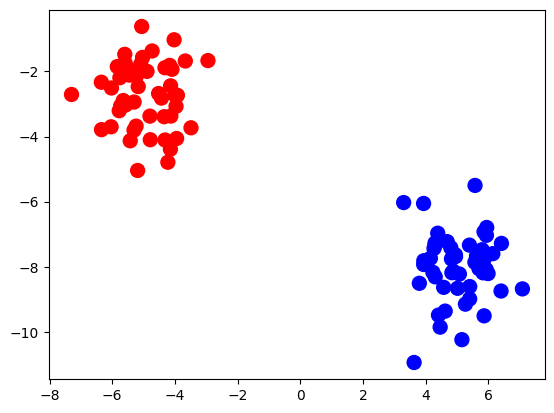

In [5]:
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", s = 100)

In [6]:
from sklearn.svm import SVC

In [7]:
svc = SVC(kernel="linear")

In [8]:
svc.fit(X,y)
y_pred = svc.predict(X)

In [9]:
y_pred

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1])

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [11]:
accuracy_score(y, y_pred)

1.0

In [13]:
confusion_matrix(y, y_pred)

array([[50,  0],
       [ 0, 50]])

In [14]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable


In [15]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

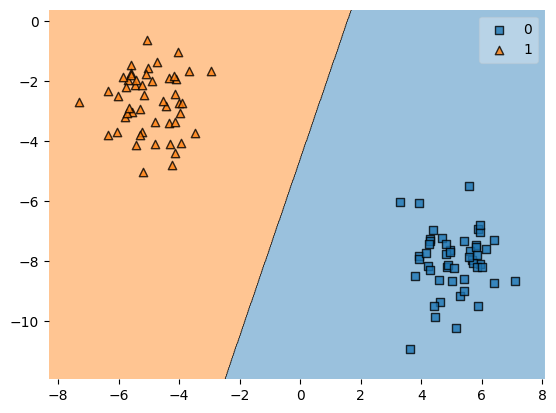

In [18]:
plot_decision_regions(X, y, clf=svc)

### Handle non linear data

In [19]:
from sklearn.datasets import make_circles

In [23]:
X,y = make_circles(100,noise=0.1,factor=0.1)

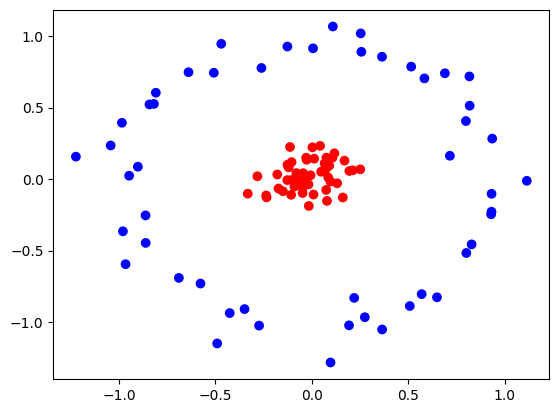

In [24]:
plt.scatter(X[:,0],X[:,1],c = y,cmap="bwr")

In [27]:
svc = SVC(kernel="linear")

In [28]:
svc.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
y_pred = svc.predict(X)

In [30]:
accuracy_score(y,y_pred)

0.66

<Axes: >

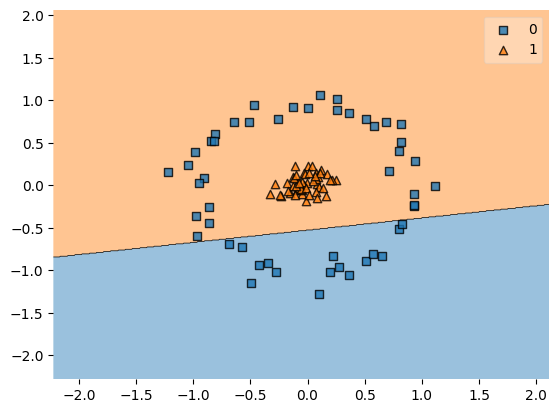

In [31]:
plot_decision_regions(X, y, clf=svc)

In [32]:
svc = SVC(kernel="rbf")
svc.fit(X,y)
y_pred = svc.predict(X)
accuracy_score(y,y_pred)

1.0

<Axes: >

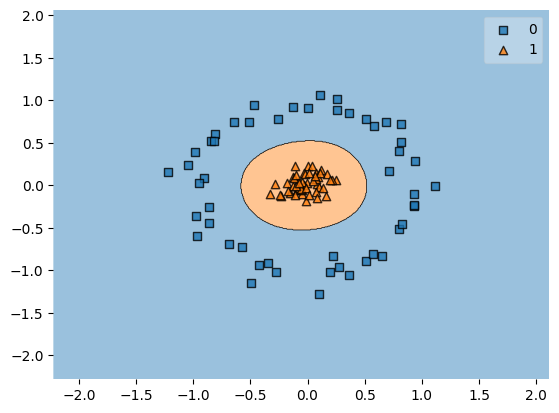

In [33]:
plot_decision_regions(X, y, clf=svc)

In [36]:
svc = SVC(kernel="poly",degree=2)
svc.fit(X,y)
y_pred = svc.predict(X)
accuracy_score(y,y_pred)

1.0

<Axes: >

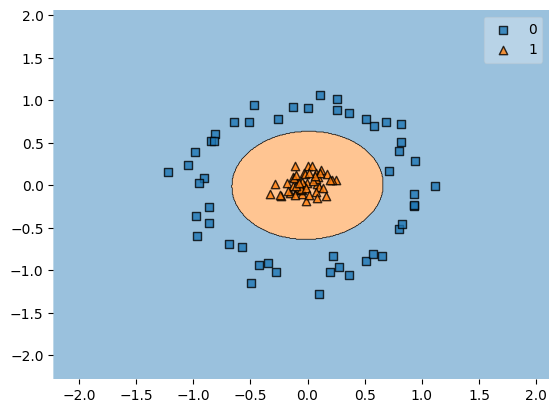

In [37]:
plot_decision_regions(X, y, clf=svc)

## What happens when C is large?

- If C is large:

    - Misclassification penalty is **very high**
    - Model tries to classify **every training point correctly**

So the algorithm sacrifices margin to avoid errors.

**Result:**
1. Margin becomes very narrow
2. Decision boundary becomes complex
3. Model tries to fit noise and outliers

**This causes overfitting.**

### Small C

SVM says:

**“It’s okay if that point is wrong. I want a clean wide margin.”**

### Large C

SVM says:

**“No mistakes allowed!”**

Boundary bends to correctly classify that single point.

Now the model becomes too sensitive to noise.

## Why SVM is Robust to Overfitting

#### 1. It focuses only on the most important points (Support Vectors)

- Unlike many algorithms that use all data points equally, SVM only cares about the points closest to the decision boundary.

These points are called **Support Vectors.**

#### 2. Maximum Margin Principle

- SVM chooses the boundary that **maximizes the margin.**

`Margin = distance between decision boundary and closest data points.`

- Why this prevents overfitting

    - `Small margin → model sensitive to small noise`
    - `Large margin → model more stable`

**“SVM chooses the safest boundary, not just a correct boundary.”**

#### 3. Regularization Parameter (C)

- SVM has a parameter C that **controls overfitting.**

    - `Large C  → tries to classify every point correctly → overfit risk`
    - `Small C  → allows some errors → better generalization`

#### 4. Kernel Trick Controls Complexity

- SVM can handle complex patterns without explicitly creating huge feature spaces.

This controlled complexity helps avoid overfitting.

`2D data → mapped to higher dimension → becomes linearly separable`

**“SVM avoids overfitting because it learns only from the most difficult points and chooses the boundary with the largest safety margin.”**

## How svm works for multi class classification?

There are **two major strategies** used in practice.

# 1. One-Vs-Rest (OVR) / One-Vs-All (OVA)

- If you have **K classes, train K binary SVM models**.

Each model learns:

`Class i  vs  All other classes`

#### Example

Suppose we have 3 classes:

1. Class A
2. Class B
3. Class C

We train 3 models

| Model   | Positive Class | Negative Class |
| ------- | -------------- | -------------- |
| Model 1 | A              | B + C          |
| Model 2 | B              | A + C          |
| Model 3 | C              | A + B          |

#### Prediction

For a new point:

Each classifier produces a **decision score** (distance from hyperplane).

Example:
| Model     | Score |
| --------- | ----- |
| A vs Rest | 2.3   |
| B vs Rest | 0.7   |
| C vs Rest | -1.5  |

**Highest score → Class A**

In [38]:
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# dataset
X, y = datasets.load_iris(return_X_y=True)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y)

# SVM model
model = SVC(kernel='linear', decision_function_shape='ovr')

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(pred[:10])

[1 0 1 1 2 1 0 1 0 2]


# 2. One-Vs-One (OVO)

Instead of class vs rest, we train classifiers between **every pair of classes**.

#### Number of Models

If there are K classes

Number of models:

        - `K(K−1)/2`

#### Example

For 3 classes:
| Classifiers |
| ----------- |
| A vs B      |
| A vs C      |
| B vs C      |

For 4 classes

| Classifiers |
| ----------- |
| A vs B      |
| A vs C      |
| A vs D      |
| B vs C      |
| B vs D      |
| C vs D      |

**Total = 6 models**

In [41]:
from sklearn.svm import SVC

model = SVC(kernel='linear', decision_function_shape='ovo')
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Which is Better?

| Method | Pros              | Cons            |
| ------ | ----------------- | --------------- |
| OVR    | Fewer models      | Class imbalance |
| OVO    | Better boundaries | More models     |
